<a href="https://colab.research.google.com/github/gulshan0201/Predictive-Model-for-Demand-Forecasting/blob/main/Data_Mining_%26_Predictive_Modelling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Predictive Model for Demand Forecasting

In [29]:
# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score


In [30]:
# 2. Load Dataset
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("Dataset Shape:", df.shape)
print(df.head())



Dataset Shape: (7043, 21)
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingM

In [31]:
# 3. Basic Information
print(df.info())
print(df.describe())

# 4. Handle Missing Values
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna()

# 5. Remove unnecessary column
df = df.drop("customerID", axis=1)

# 6. Encode Categorical Variables
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


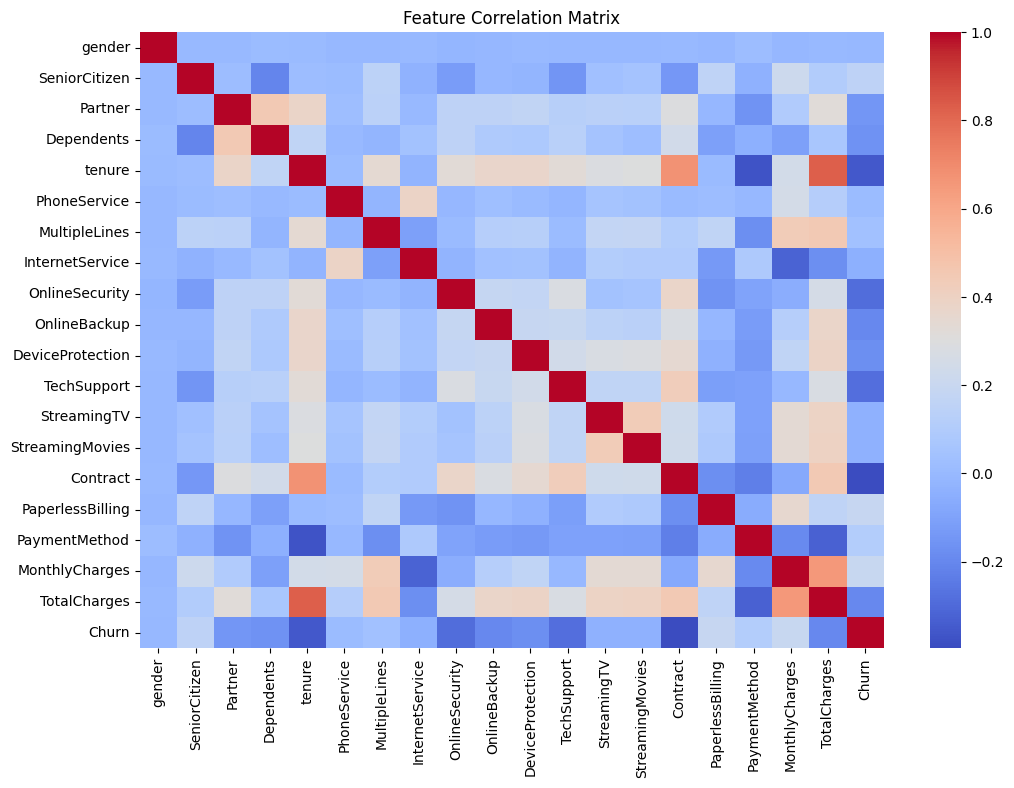

In [32]:
# 7. Correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()


In [33]:
# 8. Define Features and Target
X = df.drop("MonthlyCharges", axis=1)
y = df["MonthlyCharges"]

# 9. Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [39]:
# 10. Linear Regression Model
lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

# Evaluation
lr_mse = mean_squared_error(y_test, lr_pred)
lr_r2 = r2_score(y_test, lr_pred)

print("\nLinear Regression Results")
print("MSE:", lr_mse)
print("R2 Score:", lr_r2)


Linear Regression Results
MSE: 167.4541373004069
R2 Score: 0.8105235496048175


In [47]:
# 11. Random Forest Model
rf = RandomForestRegressor(n_estimators=200, random_state=42)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

# Evaluation
rf_mse = mean_squared_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

print("\nRandom Forest Results")
print("MSE:", rf_mse)
print("R2 Score:", rf_r2)


Random Forest Results
MSE: 1.6839091538290694
R2 Score: 0.9980946357348991


In [46]:
# 12. Model Comparison
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MSE": [lr_mse, rf_mse],
    "R2 Score": [lr_r2, rf_r2]
})

print("\nModel Comparison")
print(comparison)



Model Comparison
               Model         MSE  R2 Score
0  Linear Regression  167.454137  0.810524
1      Random Forest    1.683909  0.998095


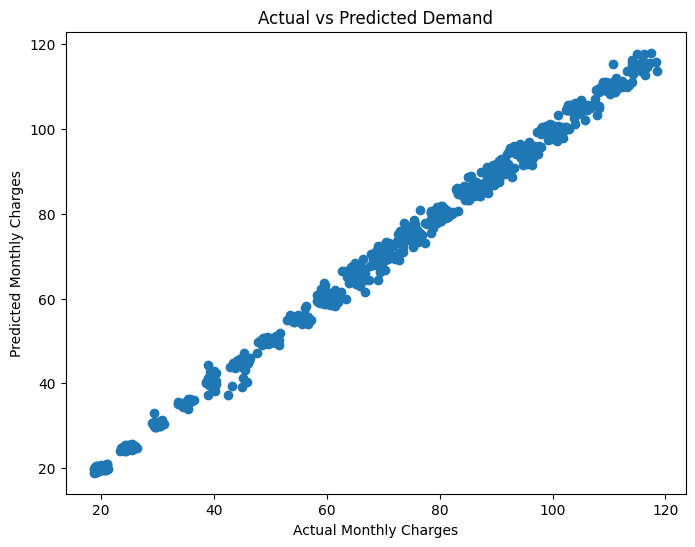

In [44]:
# 13. Actual vs Predicted Visualization
plt.figure(figsize=(8,6))
plt.scatter(y_test, rf_pred)
plt.xlabel("Actual Monthly Charges")
plt.ylabel("Predicted Monthly Charges")
plt.title("Actual vs Predicted Demand")
plt.show()

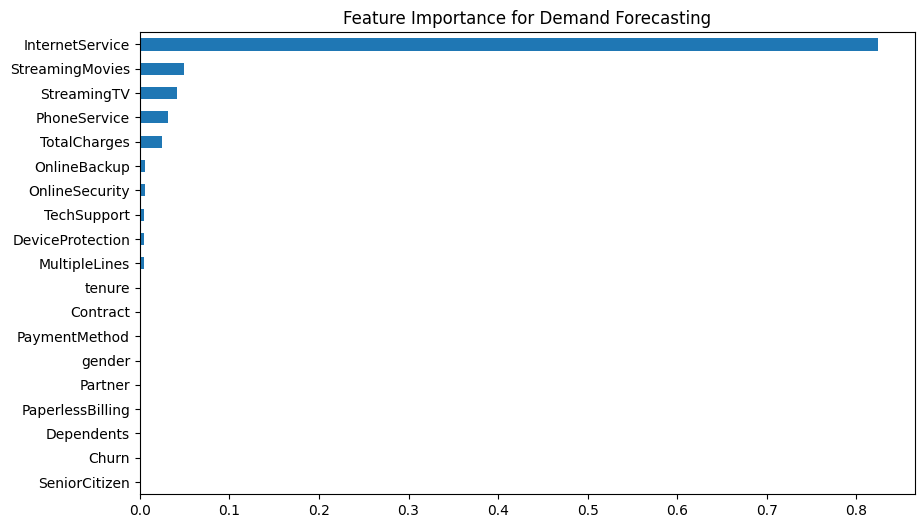

In [45]:
# 14. Feature Importance (Random Forest)
importance = pd.Series(rf.feature_importances_, index=X.columns)

importance.sort_values().plot(kind='barh', figsize=(10,6))
plt.title("Feature Importance for Demand Forecasting")
plt.show()